# QED-C Application-Oriented Benchmarks - MQT Bench Example
The notebook demonstrates modularized problem generation, execution, and analysis, where the problem generation is done using MQT Bench. 

The list of MQT Bench algorithmic benchmarks can be found at the following website: https://mqt.readthedocs.io/projects/bench/en/latest/benchmark_selection.html.

Configure and run the cell below with the desired execution settings, then proceed to run the remaining cells.

In [1]:
benchmark_name = 'wstate'
min_qubits=2
max_qubits=8
skip_qubits=1
max_circuits=3
num_shots=1000

In [2]:
import time

# MQT Bench:
from mqt.bench import get_benchmark, BenchmarkLevel

# QED-C:
from _common import metrics
from _common.qiskit import execute as ex

# IBM Qiskit:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer, AerSimulator

## Part 1: Problem Generation with MQT Bench
The code below grabs __circuits__ from MQT Bench from _min_qubits_ to _max_qubits_ using _skip_qubits_ and _max_circuits_. 

Note that we do not get any metadata from MQT Bench; we initialize __metadata__ as an empty dictionary and later use the QED-C metrics module to compute additional metrics.

In [3]:
def get_mqt_circuits(
    benchmark_name:str, 
    min_qubits:int, 
    max_qubits:int, 
    skip_qubits:int, 
    max_circuits:int
    ):
    circuits = {}
    for n_qubits in range(min_qubits, max_qubits+1, skip_qubits):
        circuits_n_qubits = {}
        for idx in range(1, max_circuits+1):
            circuits_n_qubits[str(idx)] = get_benchmark(benchmark=benchmark_name, level=BenchmarkLevel.ALG, circuit_size=n_qubits)
        circuits[str(n_qubits)] = circuits_n_qubits
    return circuits

In [4]:
# Using the above function to grab circuits. 
circuits = get_mqt_circuits(benchmark_name, min_qubits, max_qubits, skip_qubits, max_circuits)

# No metadata from MQT Bench.
metadata = {}

In [5]:
print(f"\nCircuits:\n{circuits}")
print(f"\nMetadata: \n{metadata}") # 


Circuits:
{'2': {'1': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000002A2A069D790>, '2': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000002A398064A50>, '3': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000002A2A06910D0>}, '3': {'1': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000002A3C72CF350>, '2': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000002A3C7397090>, '3': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000002A2A0690710>}, '4': {'1': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000002A2A0690590>, '2': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000002A2A069C890>, '3': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000002A398074C90>}, '5': {'1': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000002A3C73DF7D0>, '2': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x000002A2A0683C10>, '3': <qiskit.circuit.quantumcircuit.QuantumCircuit object a

## Part 2: Execution

Now that we have the Qiskit circuits, we are free to run them using any execution framework that supports Qiskit!

### Preprocessing and Additional Metrics
We first convert the _circuits_ dictionary into a flat list; additionally, we choose to compute additional metrics and store them in the metrics module.

The key variables are __flat_circuits__ and __circuit_identifies__, which will be used later.

In [6]:
# Remove the subtitle key for iterating purposes.
metadata.pop("subtitle", None)

# Copy any metadata from creation (i.e. create_time). This can be excluded if it's not of interest.
metrics.circuit_metrics = metadata

# Create a flat list of circuits for execution.
flat_circuits = []
for num_qubits in circuits.keys():
    for circuit_id in circuits[num_qubits].keys():
        flat_circuits.append(circuits[num_qubits][circuit_id])

        # Optionally compute additional circuit properties (depth, etc.) and store to metrics.
        ex.compute_and_store_circuit_info(
            circuits[num_qubits][circuit_id],
            str(num_qubits),
            str(circuit_id),
            do_transpile_metrics=True,
            use_normalized_depth=True,
        )

print(f"Flat Circuits ({len(flat_circuits)})")
print(f"\nAdditional Metrics: \n{metrics.circuit_metrics}")

C:\Users\m\.conda\envs\qiskit-test-2.0\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Flat Circuits (21)

Additional Metrics: 
{'2': {'1': {'depth': 5, 'size': 7, 'xi': 0.4, 'n2q': 2, 'tr_depth': 7, 'tr_size': 9, 'tr_xi': 0.2857142857142857, 'tr_n2q': 2}, '2': {'depth': 5, 'size': 7, 'xi': 0.4, 'n2q': 2, 'tr_depth': 7, 'tr_size': 9, 'tr_xi': 0.2857142857142857, 'tr_n2q': 2}, '3': {'depth': 5, 'size': 7, 'xi': 0.4, 'n2q': 2, 'tr_depth': 7, 'tr_size': 9, 'tr_xi': 0.2857142857142857, 'tr_n2q': 2}}, '3': {'1': {'depth': 7, 'size': 12, 'xi': 0.4444444444444444, 'n2q': 4, 'tr_depth': 10, 'tr_size': 16, 'tr_xi': 0.3076923076923077, 'tr_n2q': 4}, '2': {'depth': 7, 'size': 12, 'xi': 0.4444444444444444, 'n2q': 4, 'tr_depth': 10, 'tr_size': 16, 'tr_xi': 0.3076923076923077, 'tr_n2q': 4}, '3': {'depth': 7, 'size': 12, 'xi': 0.4444444444444444, 'n2q': 4, 'tr_depth': 10, 'tr_size': 16, 'tr_xi': 0.3076923076923077, 'tr_n2q': 4}}, '4': {'1': {'depth': 9, 'size': 17, 'xi': 0.46153846153846156, 'n2q': 6, 'tr_depth': 13, 'tr_size': 23, 'tr_xi': 0.3157894736842105, 'tr_n2q': 6}, '2': {'dept

## Running Circuits

We can choose to run on any execution platform that supports Qiskit circuits; for example, running through qBraid, _pyGSTi_, or a custom platform. 

For the sake of this demonstration, we will execute through a simple simulator.  

In [7]:
sim = Aer.get_backend("aer_simulator")
tqc = transpile(flat_circuits, sim)

ts = time.time()
result = sim.run(tqc, shots=num_shots).result()
elapsed_time = time.time() - ts

print(f"Executed {len(flat_circuits)} circuits in {elapsed_time:.3f} secs")

Executed 21 circuits in 0.081 secs


In [8]:
print(f"Results ({len(result.get_counts())}):")
print(result.get_counts())

Results (21):
[{'10': 509, '01': 491}, {'01': 533, '10': 467}, {'10': 487, '01': 513}, {'010': 345, '100': 341, '001': 314}, {'100': 327, '010': 319, '001': 354}, {'001': 358, '010': 335, '100': 307}, {'1000': 253, '0001': 276, '0010': 210, '0100': 261}, {'0010': 245, '0100': 270, '0001': 233, '1000': 252}, {'0100': 219, '0001': 244, '1000': 264, '0010': 273}, {'00001': 199, '10000': 196, '01000': 198, '00100': 201, '00010': 206}, {'01000': 206, '00010': 222, '10000': 186, '00001': 185, '00100': 201}, {'00001': 201, '10000': 209, '00100': 197, '00010': 187, '01000': 206}, {'000100': 175, '000001': 155, '010000': 166, '000010': 185, '100000': 150, '001000': 169}, {'000010': 178, '000100': 162, '100000': 164, '001000': 162, '010000': 160, '000001': 174}, {'000100': 163, '000010': 157, '001000': 170, '100000': 153, '000001': 187, '010000': 170}, {'1000000': 145, '0000100': 157, '0001000': 151, '0100000': 141, '0000001': 137, '0010000': 127, '0000010': 142}, {'0000001': 143, '0010000': 166

## Part 3: Analysis and Results
After executing the circuits, we can use the counts to compute the fidelities, store them, and plot the results.

### Computing Fidelities
The code below uses the counts from above and stores them in the metrics module, which can then be used to create plots. 

In [9]:
def ideal_dist(
    flat_circuits: list[QuantumCircuit],
    num_shots: int
):
    """
    Computes the ideal distribution to compare results to by running on a noiseless simulator.
    """
    sim = Aer.get_backend("aer_simulator")
    tqc = transpile(flat_circuits, sim)
    result = sim.run(tqc, shots=num_shots).result()
    return result.get_counts()

In [10]:
# Store execution timing metrics (elapsed_time, exec_time) for each circuit.
ex.process_circuit_results(circuits, result, elapsed_time=elapsed_time, num_shots=num_shots)

# Compute ideal distribution by running on a noiseless simulator.
ideal_counts = ideal_dist(flat_circuits, num_shots)

# Compute fidelity for each circuit by comparing against ideal distribution.
idx = 0
for num_qubits in circuits:
    for circuit_id in circuits[num_qubits]:
        counts = result.get_counts(idx)
        correct = ideal_counts[idx]
        
        # Compute the fidelity
        hf_fidelity = metrics.hellinger_fidelity_with_expected(counts, correct)
        polarization_fidelity = metrics.polarization_fidelity(counts, correct)
        
        # Store the fidelity.
        metrics.store_metric(num_qubits, circuit_id, "hf_fidelity", hf_fidelity)
        metrics.store_metric(num_qubits, circuit_id, "fidelity", polarization_fidelity)
        idx += 1

### Visualization

Now that the fidelities are stored, we can use the metrics module to create plots. 

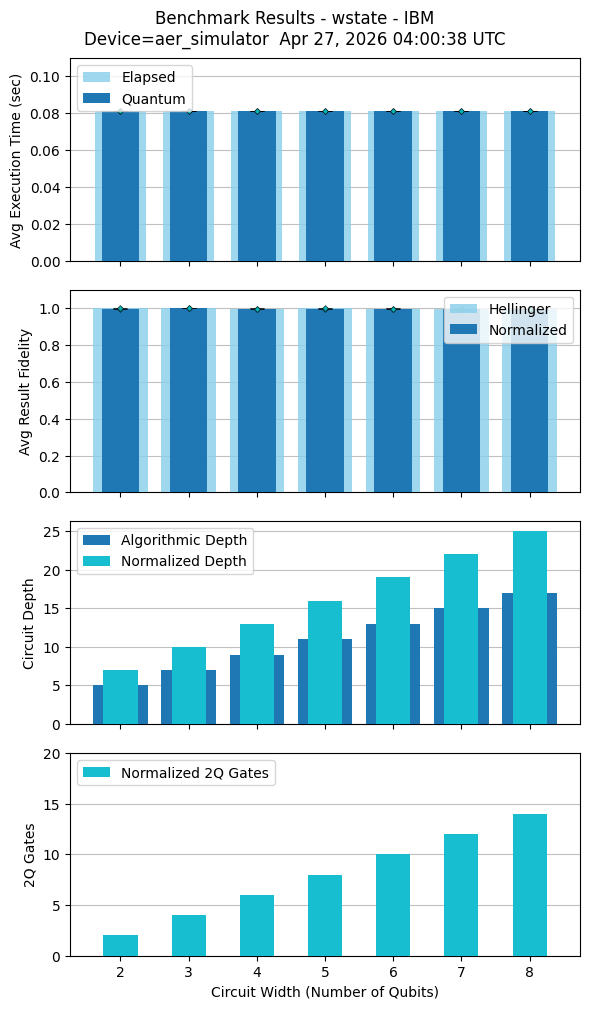

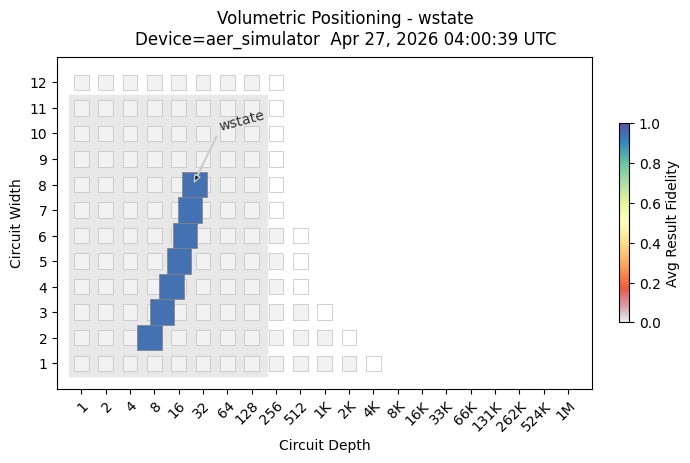

In [11]:
# Compute statistics for metrics.
metrics.aggregate_metrics()

# Set information for plot titles.
benchmark_name = benchmark_name
provider_name = "IBM"
device_name = "aer_simulator"

# Set plot titles.
benchmark_title = f"{benchmark_name}"
subtitle = f"Benchmark Results - {benchmark_title} - {provider_name}"
metrics.circuit_metrics["subtitle"] = f"device = {device_name}"

# Determine which metrics to plot.
filters = ["execute", "fidelity", "hf_fidelity", "depth", "2q", "vbplot"]

# Plot the metrics.
metrics.plot_metrics(subtitle, filters=filters)